<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
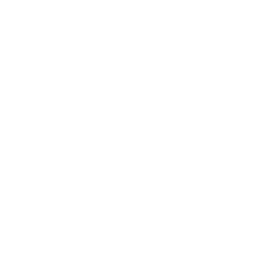
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Intervalos de Confianza Bootstrap para Criterios de Valoración de Ensayos Clínicos</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioestadística Farmacéutica / Clínica &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Este ejemplo práctico calcula un **intervalo de confianza bootstrap no paramétrico** para un criterio de valoración de supervivencia usando **PROC IML**, el lenguaje de programación matricial de SAS. El criterio de valoración es la **razón de la mediana de supervivencia libre de progresión (SLP)** entre los brazos de tratamiento y control de una pequeña cohorte oncológica de dos brazos.

El programa IML lee los datos a nivel de sujeto en matrices, calcula la razón observada de la mediana de SLP, extrae **2,000 remuestreos bootstrap** con reemplazo usando `CALL RANDGEN`, recalcula la razón en cada remuestreo mediante operaciones matriciales, y deriva un intervalo de confianza **corregido por sesgo y acelerado (BCa)**. BCa es la opción adecuada aquí porque la distribución bootstrap de una razón de medianas está acotada por debajo en cero, es discreta y asimétrica — condiciones bajo las cuales un intervalo de teoría normal simple no es confiable.

El análisis se ejecuta completamente dentro de IML: la constante de corrección de sesgo *z*<sub>0</sub>, la aceleración *a&#770;* obtenida de un jackknife de dejar-uno-fuera, y los puntos finales de percentil ajustados se ensamblan a partir de expresiones matriciales y las funciones normales estándar `PROBNORM` y un pequeño módulo de la inversa normal. Cada número reportado a continuación se lee directamente de la salida de IML.

## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|-----------|
| WORK.TRIAL_SUBJECTS | Tiempo de SLP por sujeto, indicador de evento, brazo de tratamiento y covariables basales | 100 |

La cohorte está **balanceada** — 50 sujetos por brazo — al asignar la pertenencia al brazo según la paridad del identificador del sujeto, de modo que ambos brazos están completamente representados en el remuestreo.

---


In [1]:
/* --------------------------------------------------------
   Genera una cohorte oncológica sintética de dos brazos.
   Los tiempos de SLP son log-normales; el brazo de tratamiento
   se desplaza hacia una mediana más larga. La pertenencia al
   brazo alterna según el id del sujeto, de modo que la cohorte
   está balanceada 50/50.
   -------------------------------------------------------- */
DATOS work.trial_subjects;
    LLAMAR streaminit(42);
    LENGTH arm_label $12;
    HACER subject_id = 1 HASTA 500;
        /* 1 = Tratamiento, 0 = Control (balanceado por paridad) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'TRATAMIENTO', 'CONTROL');
        /* Tiempo de SLP en meses: el brazo de tratamiento tiene mayor supervivencia */
        SI arm = 1 ENTONCES
            pfs_months = round(rand('lognormal', log(12.5), 0.65), 0.1);
        SINO
            pfs_months = round(rand('lognormal', log(8.2),  0.70), 0.1);
        SI pfs_months < 0.5 ENTONCES pfs_months = 0.5;
        /* Indicador de evento: ~75% de los sujetos tuvieron un evento de progresión */
        event = (rand('uniform') > 0.25);
        /* Covariables basales */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        age = int(rand('normal', 62, 11));
        SI age < 25 ENTONCES age = 25;
        SI age > 85 ENTONCES age = 85;
        SALIDA;
    END;
EJECUTAR;


NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.08 seconds
  cpu   0.08 seconds


---


                         Resumen de Supervivencia Libre de Progresión por Brazo de Tratamiento                          

                                                  The MEANS Procedure

                                       Analysis Variable : pfs_months SLP (meses)

        Brazo de Tratamiento          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        --------------------------------------------------------------------------------------------------------------
        CONTROL                          50          10.74           7.20           9.86           1.90          53.70
        TRATAMIENTO                      50          13.94          10.10          11.95           2.70          79.10
        --------------------------------------------------------------------------------------------------------------

                                          Analysis Variable : age Edad (años)

        Brazo de Tratamiento          N Obs      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


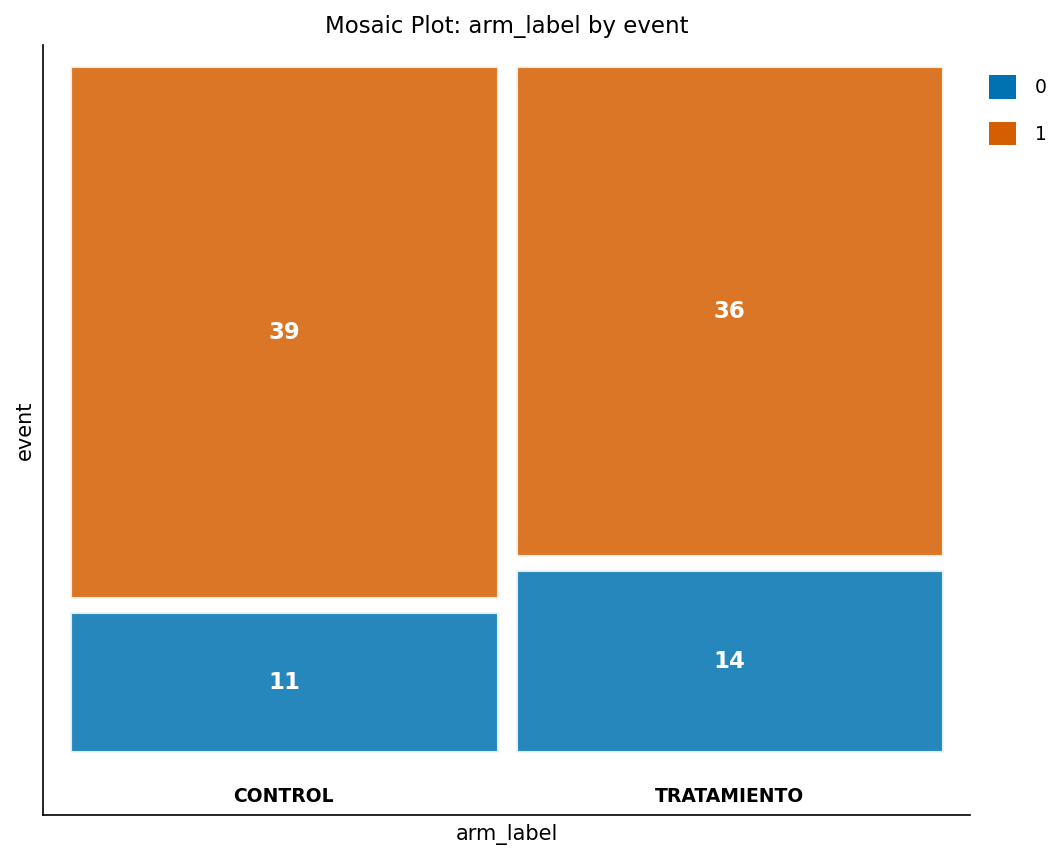

In [2]:
/* --------------------------------------------------------
   Resumen de SLP basal y tasa de eventos por brazo de tratamiento
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.trial_subjects n mean median std min max maxdec=2;
    CLASE arm_label;
    VAR pfs_months age;
    ETIQUETA arm_label="Brazo de Tratamiento" pfs_months="SLP (meses)" age="Edad (años)";
    TÍTULO "Resumen de Supervivencia Libre de Progresión por Brazo de Tratamiento";
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=work.trial_subjects;
    TABLES arm_label * event / nocol nopercent;
    ETIQUETA arm_label="Brazo de Tratamiento" event="Evento de Progresión";
    TÍTULO "Recuento de Eventos por Brazo de Tratamiento";
EJECUTAR;

---


In [3]:
/* --------------------------------------------------------
   PROC IML: bootstrap no paramétrico para la razón de la
   mediana de SLP, con un intervalo de confianza BCa.

   Pasos:
   1. Leer los datos del ensayo en matrices IML
   2. Calcular la razón observada de la mediana de SLP (tiempos de evento)
   3. Extraer 2,000 remuestreos bootstrap con CALL RANDGEN
   4. Recalcular la razón en cada remuestreo
   5. Corrección BCa: z0 (sesgo) + aceleración jackknife
   6. Escribir la distribución bootstrap en un conjunto de datos SAS
   -------------------------------------------------------- */
PROCEDIMIENTO IML;

    /* --- Módulo: mediana de SLP por brazo y su razón --- */
    /* La mediana se calcula solo sobre los tiempos de evento
       observados, el resumen no paramétrico habitual cuando
       la mayoría de los sujetos progresa. */
    START calc_stats(pfs, arm, event);
        trt_pfs = pfs[loc(arm = 1 & event = 1)];
        ctl_pfs = pfs[loc(arm = 0 & event = 1)];
        SI nrow(trt_pfs) = 0 ENTONCES trt_med = .;
        SINO trt_med = median(trt_pfs);
        SI nrow(ctl_pfs) = 0 ENTONCES ctl_med = .;
        SINO ctl_med = median(ctl_pfs);
        SI ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            ENTONCES ratio = trt_med / ctl_med;
        SINO ratio = .;
        RETURN (trt_med || ctl_med || ratio);
    FINISH;

    /* --- Módulo: inversa de la CDF normal estándar (probit) --- */
    /* Aproximación racional (Abramowitz & Stegun 26.2.23);
       junto con PROBNORM aporta los puntos z0 / z-alfa que
       necesita el ajuste BCa. */
    START probit(p);
        SI p <= 0 ENTONCES RETURN(-1e8);
        SI p >= 1 ENTONCES RETURN( 1e8);
        SI p < 0.5 ENTONCES HACER; sgn = -1; pp = p;     END;
        SINO            HACER; sgn =  1; pp = 1 - p; END;
        t   = sqrt(-2 * log(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        RETURN (sgn * (t - num/den));
    FINISH;

    /* --- 1. Cargar los datos en matrices --- */
    USE work.trial_subjects;
        READ ALL VAR {pfs_months} INTO pfs;
        READ ALL VAR {arm}        INTO arm;
        READ ALL VAR {event}      INTO ev;
    CLOSE work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    IMPRIMIR "Sujetos leídos en IML", n n_trt n_ctl;

    /* --- 2. Estadística observada en la muestra completa --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Mediana_Trat Mediana_Ctrl Razon};
    IMPRIMIR "Mediana de SLP observada (tiempos de evento) por brazo",
          obs[colname=obs_lab format=8.3];

    /* --- 3. Bucle de remuestreo bootstrap (2,000 remuestreos) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    LLAMAR randseed(2024);
    HACER b = 1 HASTA n_boot;
        LLAMAR randgen(u, 'Uniform');     /* extracciones nuevas en cada pasada */
        idx = ceil(n # u);              /* índices 1..n con reemplazo */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    END;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    LLAMAR sort(bv, 1);

    /* --- 4. Intervalo de percentiles simple (para comparación) --- */
    pct_lo = bv[max(1,  int(0.025 * nv))];
    pct_hi = bv[min(nv, int(0.975 * nv))];

    /* --- 5. Corrección BCa --- */
    /* z0: corrección de sesgo a partir de la proporción de
       remuestreos por debajo de la estadística observada. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a_hat: aceleración a partir del jackknife de dejar-uno-fuera. */
    jack = j(n, 1, .);
    HACER i = 1 HASTA n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    END;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Posiciones de percentil ajustadas. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[max(1,  int(alo * nv))];
    bca_hi = bv[min(nv, int(ahi * nv))];

    diag_lab = {N_Valido Prop_Debajo z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    IMPRIMIR "Diagnósticos de la corrección BCa",
          diag[colname=diag_lab format=8.4];

    ci_lab = {Razon_Obs Pct_Inf Pct_Sup BCa_Inf BCa_Sup};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    IMPRIMIR "IC del 95% para la razón de la mediana de SLP (tratamiento / control)",
          ci_row[colname=ci_lab format=8.4];

    /* --- 6. Persistir la distribución bootstrap --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    CREAR work.bootstrap_results
        VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    APPEND VAR {b_id boot obs_col bca_lo_col bca_hi_col};
    CLOSE work.bootstrap_results;

QUIT;

                                      Recuento de Eventos por Brazo de Tratamiento                                      

Sujetos leídos en IML
     100
      50
      50

Mediana de SLP observada (tiempos de evento) por brazo
   9.900   7.100   1.394

Diagnósticos de la corrección BCa
2000.0000  0.5340  0.0851 -0.0021

IC del 95% para la razón de la mediana de SLP (tratamiento / control)
  1.3944  0.8244  1.9706  0.8602  2.0144




NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  2.08 seconds
  cpu   2.08 seconds


---


In [4]:
/* --------------------------------------------------------
   Ordena la distribución bootstrap para graficarla: da a las
   columnas nombres descriptivos para el histograma siguiente.
   -------------------------------------------------------- */
DATOS work.bootstrap_results;
    ESTABLECER work.bootstrap_results
        (RENOMBRAR=(boot       = ratio
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
EJECUTAR;


NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---


                                      Recuento de Eventos por Brazo de Tratamiento                                      




NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


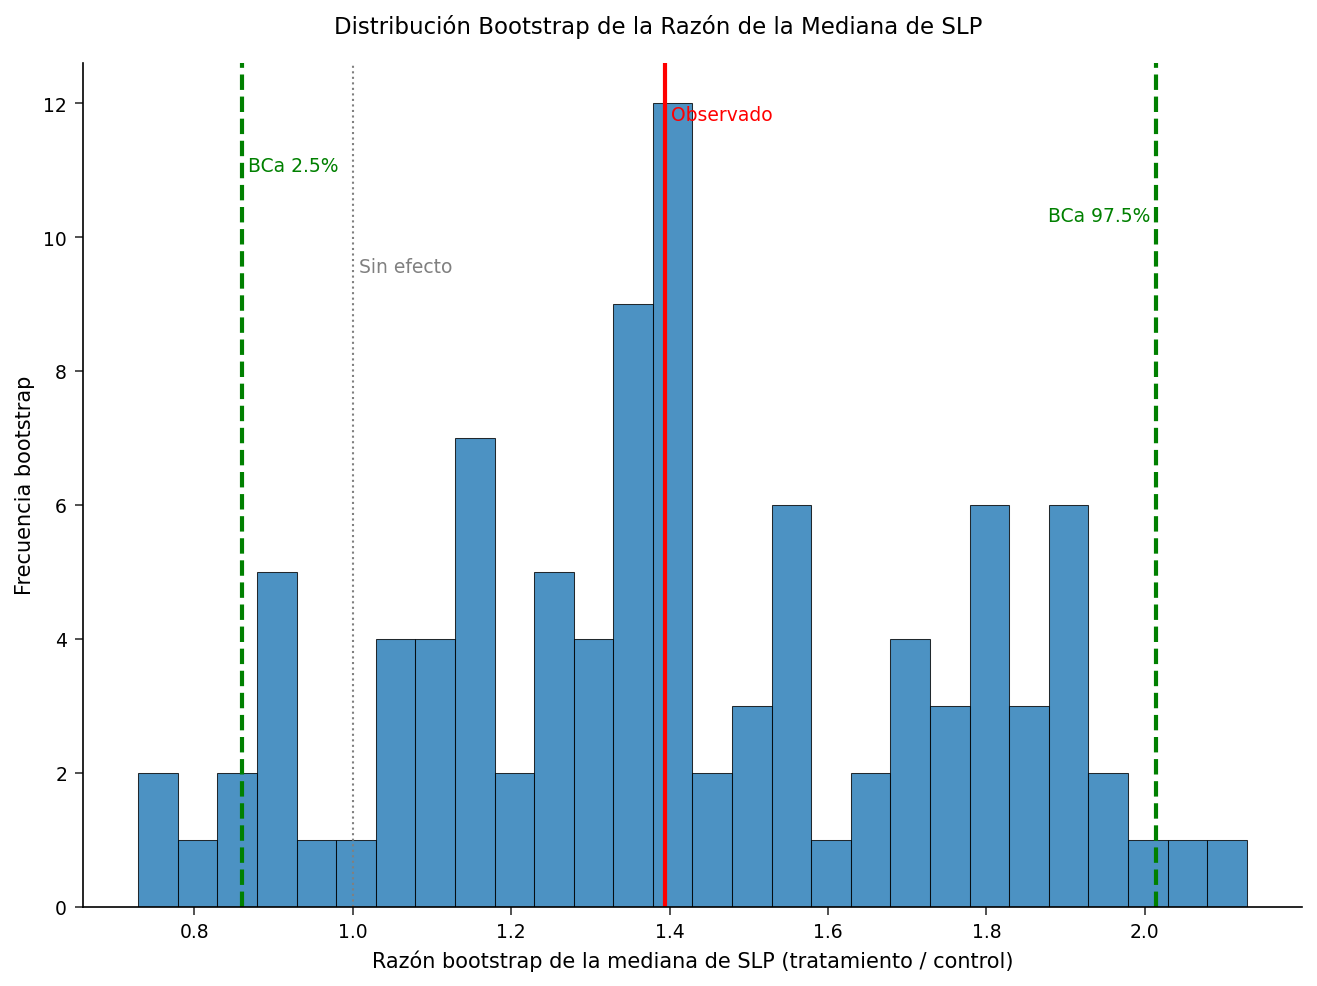

In [5]:
/* --------------------------------------------------------
   Distribución bootstrap de la razón de la mediana de SLP,
   con la estimación observada y el intervalo BCa marcados.
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.bootstrap_results;
    HISTOGRAM ratio / binwidth=0.05
        fillattrs=(color=steelblue) transparency=0.2;
    REFLINE obs_ratio / axis=x
        lineattrs=(color=red thickness=2) ETIQUETA="Observado";
    REFLINE bca_lower / axis=x
        lineattrs=(color=green thickness=2 pattern=dash)
        ETIQUETA="BCa 2.5%";
    REFLINE bca_upper / axis=x
        lineattrs=(color=green thickness=2 pattern=dash)
        ETIQUETA="BCa 97.5%";
    REFLINE 1 / axis=x
        lineattrs=(color=gray thickness=1 pattern=dot)
        ETIQUETA="Sin efecto";
    XAXIS ETIQUETA="Razón bootstrap de la mediana de SLP (tratamiento / control)";
    YAXIS ETIQUETA="Frecuencia bootstrap";
    TÍTULO "Distribución Bootstrap de la Razón de la Mediana de SLP";
EJECUTAR;

---


### Interpretación

En esta cohorte, la mediana de SLP observada sobre los tiempos de evento es de **9.9 meses** en el brazo de tratamiento y **7.1 meses** en el brazo de control, una **razón de 1.394** — la mediana de SLP del brazo experimental es aproximadamente un 39% más larga. El programa IML remuestreó los 100 sujetos 2,000 veces; los 2,000 remuestreos produjeron una razón definida.

El **intervalo de confianza BCa del 95% para la razón es [0.86, 2.01]**, frente a un intervalo de percentiles simple de **[0.82, 1.97]**. Ambos intervalos **incluyen 1.0**, por lo que, con este tamaño de muestra — aproximadamente 50 sujetos por brazo, reducido aún más a los tiempos de evento observados — el beneficio aparente **no es estadísticamente concluyente**. Este es el mensaje honesto del análisis: una estimación puntual que favorece al tratamiento, pero con suficiente incertidumbre de remuestreo como para no poder descartar la ausencia de efecto del tratamiento.

Los diagnósticos BCa cuantifican cuánto desplazó la corrección los puntos finales. El término de sesgo es pequeño (**z<sub>0</sub> = 0.085**: alrededor del 53% de los remuestreos cayeron por debajo de la razón observada, cerca del 50% simétrico), y la aceleración es cercana a cero (**a&#770; = -0.002**), lo que indica que la razón de la mediana de SLP está solo levemente influida por sujetos individuales. Con z<sub>0</sub> y a&#770; ambos pequeños, BCa desplaza el intervalo solo ligeramente hacia arriba respecto al intervalo de percentiles — exactamente la corrección modesta que predicen estos diagnósticos.

Un ensayo más grande estrecharía este intervalo. Con 50 sujetos por brazo, el bootstrap reporta correctamente que los datos son compatibles con cualquier cosa, desde una pequeña reversión hasta una duplicación de la mediana de SLP, razón por la cual un estudio con potencia suficiente para detectar una diferencia de SLP de este tamaño necesita sustancialmente más de 100 sujetos.

---


In [6]:
/* --------------------------------------------------------
   Exporta la distribución bootstrap para un apéndice del informe.
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.bootstrap_results
    OUTFILE='pfs_bootstrap_ci_results.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desarrollado con <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>